In [1]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, PretrainedConfig

import pandas as pd
import torch
import torch.nn.functional as F

In [5]:
#print(torch.cuda.get_device_name(0))

In [3]:
from datetime import datetime
# extract date object
today = datetime.now().date().strftime("%d-%m-%y")
# format date
print('Date String', today)

Date String 20-08-26


In [4]:
data = pd.read_csv("../data/raw/wndp_api.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/wndp_api.csv'

In [5]:
tokenizer = AutoTokenizer.from_pretrained("wndp-exp/checkpoint-1670/")
model = AutoModelForSequenceClassification.from_pretrained("wndp-exp/checkpoint-1670/")
config = PretrainedConfig.from_pretrained("wndp-exp/checkpoint-1670/")

You are using a model of type distilbert to instantiate a model of type . This is not supported for all configurations of models and can yield errors.


In [6]:
sample = "found on the ground by window - breathing hard, eyes not open, couldn't stand up, ants covering him, some spazmotic movements of leg, wing, seemed better today. emaciated fledgling with torticollis. Neurologic: torticollis Legs / Feet / Hocks: not using legs. poor prognosis given age, emaciation, and degree of debilitation"

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print()

Using device: cuda



In [8]:
device = torch.device("cuda")
model = model.to(device)

In [9]:
#?tokenizer

In [10]:
def _pre(text, device):
    tokens = tokenizer(text, return_tensors="pt")
    tokens = {k: v.to(device) for k,v in tokens.items()}
    return tokens

def _inf(model, tokens):
    out = model(**tokens)
    return out

def _post(out):
    probs = F.sigmoid(out.logits.squeeze().detach().cpu())
    preds = (probs > 0.5).int()
    labels = [config.id2label[idx] for idx, label in enumerate(preds) if label == 1.0]
    return labels

def infer(model, text):
    tokens = _pre(text, model.device)
    if (len(tokens['input_ids'][0]) <= 512):
        out = _inf(model, tokens)
        pred = _post(out)
        return pred
    else:
        return 'long or short text, working on the bug'

In [11]:
infer(model, sample)

['neurologic_disease', 'nutritional_disease']

In [12]:
data.iloc[7335]

patient_id                                              3312068
text          Flapping in puddle in gutter unable to get out...
terms                 ['Neurologic disease', 'Physical injury']
Name: 7335, dtype: object

In [13]:
data.shape

(15640, 3)

In [14]:
pred_df = data[~data.text.isna()]
pred_df = pred_df[pred_df.text.str.len()>1]

In [15]:
%%time
predictions = []
for _,row in pred_df.iterrows():
    #print(row["text"])
    #print("actuals: ", row["terms"])
    pred = infer(model, row["text"])
    #print("predicts: ", pred)
    predictions.append(pred)
    if len(predictions)%1000 == 0:
        print(len(predictions))
    #print(len(predictions))
    #print("="*20)

Token indices sequence length is longer than the specified maximum sequence length for this model (574 > 512). Running this sequence through the model will result in indexing errors


1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
CPU times: total: 1min 45s
Wall time: 4min 18s


In [16]:
pred_df.iloc[358].text

'boat captain scooped out of the water. B1, B2 - systemic/infectious disease, red tide/toxicosis. Neurologic: ataxia, generalized paresis Feathers / Fur / Skin: feather lice. A: Juvenile gull presenting with generalized paresis and ataxia consistent with brevetoxicosis. Fundic WNL, F-stain negative. No hooks on plop rads. R/o other infectious dz vs toxin vs systemic dz. \r\nP: Re-feeding plan P-care 3, 4, 5% -> FA/FS x3 -> WF. 1/8 seatab PO SID. Metronidazole 25 mg/kg PO BID, melena watch BID, clean/express cloaca TID. PO fluids 4% BW BID. Vet check neuro, lactate tomorrow. Vet check progress in 3d'

In [17]:
#aa = data[data.text.str.len() == data.text.str.len().max()].text.values[0]

In [18]:
infer(model, sample)

['neurologic_disease', 'nutritional_disease']

In [19]:
len(predictions)    

15634

In [20]:
#predictions

In [21]:
pred_df.shape

(15634, 3)

In [22]:
pred_df['predictions'] = predictions

In [23]:
pred_df.to_excel('../data/external/predictions_'+today+'.xlsx')

In [24]:
pred_df.set_index('patient_id', inplace = True)
pred_df.head()

,text,terms,predictions
patient_id,,,
2224052,"Orphaned. Body: fleas, flea dirt",['Clinically healthy'],[clinically_healthy]
554625,can't fly. expired shortly after intake,['Nonspecific'],[nonspecific]
2683764,Orphaned. Body: ECTOPALASHES - FLEAS,['Clinically healthy'],[clinically_healthy]
979650,Collision - Car. Fx- Humerus (L) ; Nutritional...,"['Neurologic disease', 'Nutritional disease', ...","[neurologic_disease, nutritional_disease, phys..."
1942311,"NSF, orphaned. NSF, orphaned",['Clinically healthy'],[clinically_healthy]


In [25]:
import ast
pred_df['terms'] = pred_df.terms.apply(ast.literal_eval)

In [26]:
from sklearn.metrics import multilabel_confusion_matrix
def add_one_hot(df, column):
    _df = df.copy()
    ohe = (pd.get_dummies(_df[column].apply(pd.Series).stack(), dtype="int")
             .groupby(level=0)
             .sum()
          )
    return pd.merge(_df, ohe, left_index=True, right_index=True)

In [27]:
ydf_true = add_one_hot(pred_df, column='terms')
ydf_pred = add_one_hot(pred_df, column='predictions')
ydf_true.columns = ydf_true.columns.str.lower().str.replace(" ", "_")

In [28]:
ydf_true.shape

(15634, 14)

In [29]:
ydf_true.index.nunique()

15634

In [30]:
cases = ydf_pred.index.unique().tolist()
y = ydf_true.loc[cases]
y.shape

(15569, 14)

In [31]:
columns_list = ['clinically_healthy',
 'dermatologic_disease',
 'gastrointestinal_disease',
 'hematologic_disease',
 'neurologic_disease',
 'nonspecific',
 'nutritional_disease',
 'ocular_disease',
 'physical_injury',
 'respiratory_disease',
 'urogenital_disease']

vis_arr  = multilabel_confusion_matrix(y[columns_list], ydf_pred[columns_list])
vis_arr

array([[[11399,   126],
        [  101,  3943]],

       [[14577,    52],
        [   85,   855]],

       [[14554,    45],
        [   66,   904]],

       [[14905,    36],
        [   29,   599]],

       [[12654,   135],
        [  141,  2639]],

       [[14389,    97],
        [  136,   947]],

       [[13722,    89],
        [   81,  1677]],

       [[14573,    62],
        [   68,   866]],

       [[ 9396,   261],
        [  169,  5743]],

       [[14210,    89],
        [   85,  1185]],

       [[15008,    44],
        [   29,   488]]], dtype=int64)

In [32]:
# Calculate precision, recall and f1-score per label
from sklearn.metrics import precision_recall_fscore_support
precision, recall, f1, _ = precision_recall_fscore_support(y[columns_list], ydf_pred[columns_list], average=None)

In [33]:
# Print scores  
labels = columns_list
for i in range(len(labels)):
    print(f'Label: {labels[i]}') 
    print(f'Precision: {precision[i]:.3f}')
    print(f'Recall: {recall[i]:.3f}') 
    print(f'F1-score: {f1[i]:.3f}\n')

Label: clinically_healthy
Precision: 0.969
Recall: 0.975
F1-score: 0.972

Label: dermatologic_disease
Precision: 0.943
Recall: 0.910
F1-score: 0.926

Label: gastrointestinal_disease
Precision: 0.953
Recall: 0.932
F1-score: 0.942

Label: hematologic_disease
Precision: 0.943
Recall: 0.954
F1-score: 0.949

Label: neurologic_disease
Precision: 0.951
Recall: 0.949
F1-score: 0.950

Label: nonspecific
Precision: 0.907
Recall: 0.874
F1-score: 0.890

Label: nutritional_disease
Precision: 0.950
Recall: 0.954
F1-score: 0.952

Label: ocular_disease
Precision: 0.933
Recall: 0.927
F1-score: 0.930

Label: physical_injury
Precision: 0.957
Recall: 0.971
F1-score: 0.964

Label: respiratory_disease
Precision: 0.930
Recall: 0.933
F1-score: 0.932

Label: urogenital_disease
Precision: 0.917
Recall: 0.944
F1-score: 0.930



In [34]:
ydf_pred.head()

,text,terms,predictions,clinically_healthy,dermatologic_disease,gastrointestinal_disease,hematologic_disease,"long or short text, working on the bug",neurologic_disease,nonspecific,nutritional_disease,ocular_disease,physical_injury,respiratory_disease,urogenital_disease
patient_id,,,,,,,,,,,,,,,
2224052,"Orphaned. Body: fleas, flea dirt",[Clinically healthy],[clinically_healthy],1,0,0,0,0,0,0,0,0,0,0,0
554625,can't fly. expired shortly after intake,[Nonspecific],[nonspecific],0,0,0,0,0,0,1,0,0,0,0,0
2683764,Orphaned. Body: ECTOPALASHES - FLEAS,[Clinically healthy],[clinically_healthy],1,0,0,0,0,0,0,0,0,0,0,0
979650,Collision - Car. Fx- Humerus (L) ; Nutritional...,"[Neurologic disease, Nutritional disease, Phys...","[neurologic_disease, nutritional_disease, phys...",0,0,0,0,0,1,0,1,0,1,0,0
1942311,"NSF, orphaned. NSF, orphaned",[Clinically healthy],[clinically_healthy],1,0,0,0,0,0,0,0,0,0,0,0


In [35]:
labels  = columns_list
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
def print_confusion_matrix(confusion_matrix, axes, class_label, class_names, fontsize=14):
    confusion_matrix = confusion_matrix.astype('float') / confusion_matrix.sum(axis=1)[:, np.newaxis]
    #print(confusion_matrix)
    df_cm = pd.DataFrame(
        confusion_matrix, index=class_names, columns=class_names,
    )

    try:
        heatmap = sns.heatmap(df_cm, annot=True, fmt=".2f", cbar=False, ax=axes)
    except ValueError:
        raise ValueError("Confusion matrix values must be integers.")
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right', fontsize=fontsize)
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right', fontsize=fontsize)
    axes.set_ylabel('True label')
    axes.set_xlabel('Predicted label')
    axes.set_title(class_label)

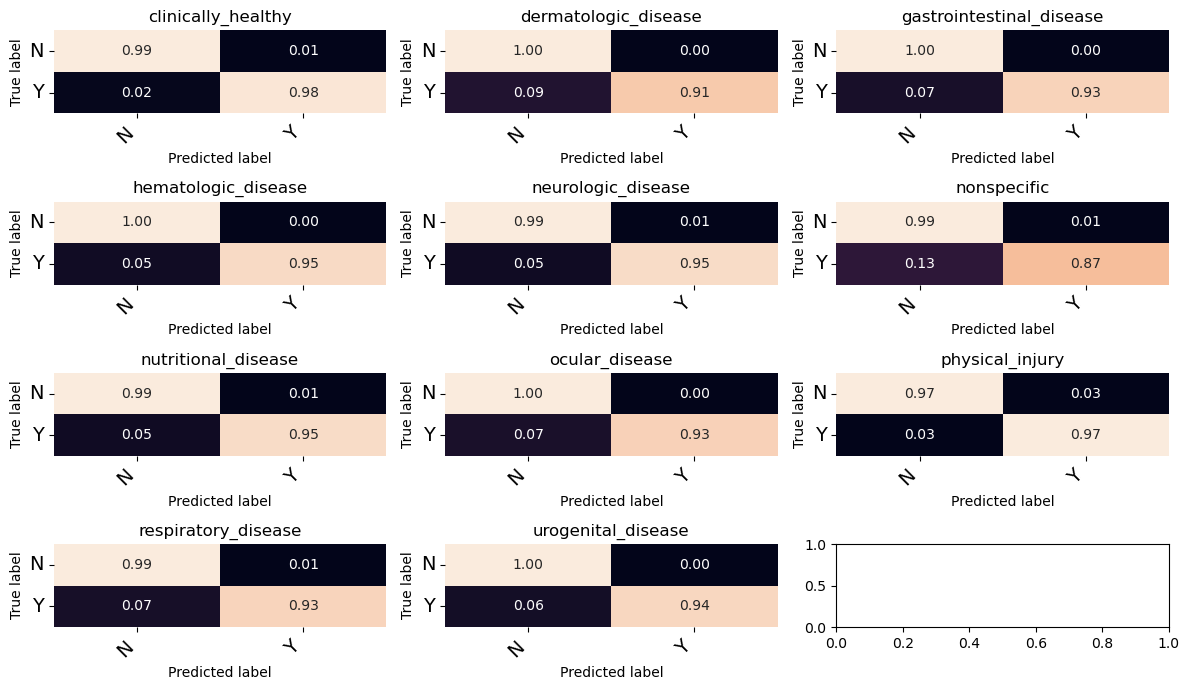

In [36]:
fig, ax = plt.subplots(4, 3, figsize=(12, 7))
for axes, cfs_matrix, label in zip(ax.flatten(), vis_arr, labels):
    print_confusion_matrix(cfs_matrix, axes, label, ["N", "Y"])

fig.tight_layout()
plt.savefig('../reports/figures/confusion_matrix_'+today+'.png', dpi = 600)
plt.show()

In [37]:
import sklearn.metrics as skm
#import mlmc

In [38]:
#import os
#os.getcwd()

In [39]:
%run mlcm.py

### Computing confusion matrix using 'MLCM"

In [40]:
conf_mat,normal_conf_mat = cm(y[columns_list].values, ydf_pred[columns_list].values)
print('\nRaw confusion Matrix:')
print(conf_mat)
print('\nNormalized confusion Matrix (%):')
print(normal_conf_mat) 

MLCM has one extra row (NTL) and one extra column (NPL).        
Please read the following paper for more information:
        Heydarian et al., MLCM: Multi-Label Confusion Matrix, IEEE Access,2022        
To skip this message, please add parameter "print_note=False"
        e.g., conf_mat,normal_conf_mat = mlcm.cm(label_true,label_pred,False)

Raw confusion Matrix:
[[3943    1    5    5    8   37   13    2   34    4    2    2]
 [   8  855    3    1    2    3    5    5   30    3    2   51]
 [   6    4  904    0    7    5   12    3   30    6    5   39]
 [   0    8    2  599    3    3    5    2   18    1    1   14]
 [   8   13   13    8 2639   18   17   22   70   17   10   88]
 [  57    8    5    7   16  947   13    0   30   13    1    4]
 [  15    5    6    5   10    5 1677    5   30    2    6   47]
 [   5    2    4    0   12    4    3  866   24    6    1   46]
 [  24   15   11   10   81   21   25   36 5743   53   27   93]
 [   6    1    2    3   12    9    7    4   31 1185    1   54]
 

In [41]:
processed_categories = []
for category in columns_list:
    category = category.replace('_disease', '')
    category = category.replace('_', ' ')
    category = category.capitalize()
    processed_categories.append(category)
columns_list
y_lables  = processed_categories + ['No True Labels']
x_lables  = processed_categories + ['No Predicted Label']

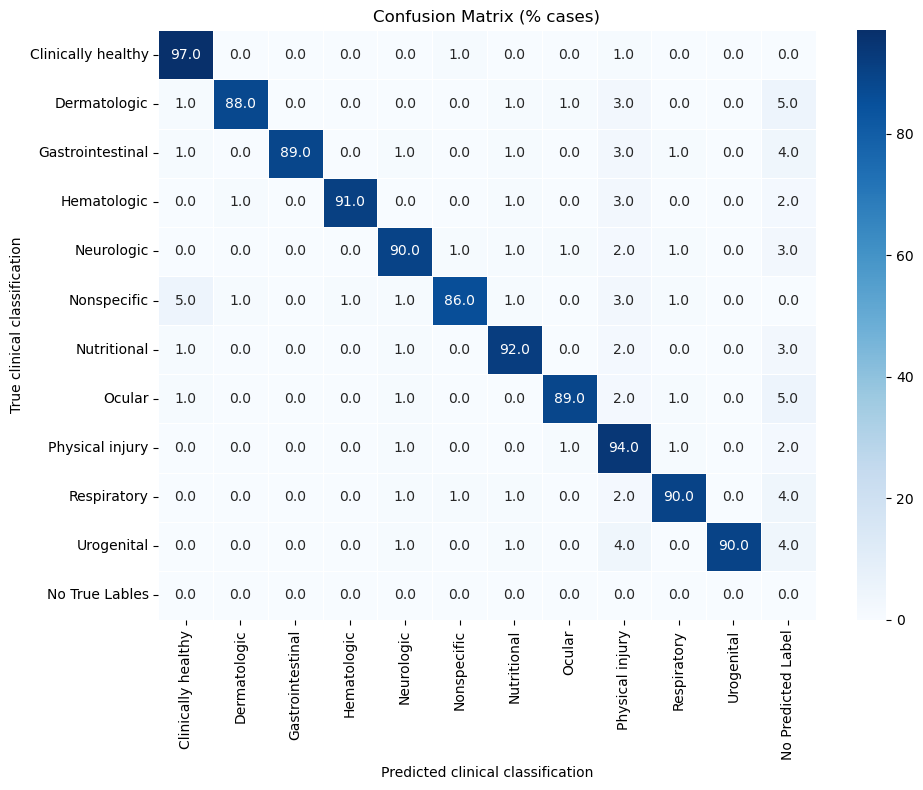

In [42]:
# Create the heatmap
plt.figure(figsize=(10,8))
ax = sns.heatmap(normal_conf_mat, 
                cmap="Blues",
                annot=True, 
                fmt=".1f",
                linewidths=.5)

# Customize the plot
ax.set_title("Confusion Matrix (% cases)")
ax.set_xlabel("Predicted clinical classification")
ax.set_ylabel("True clinical classification")
# Set x-axis tick labels
ax.set_xticklabels(x_lables, fontsize=10, rotation = 90) 

# Set y-axis tick labels 
ax.set_yticklabels(y_lables, fontsize=10, rotation = 0)
plt.tight_layout()
plt.savefig('../reports/figures/Confusion_matrix_normalized_'+today+'.png', dpi = 600)  
plt.show()

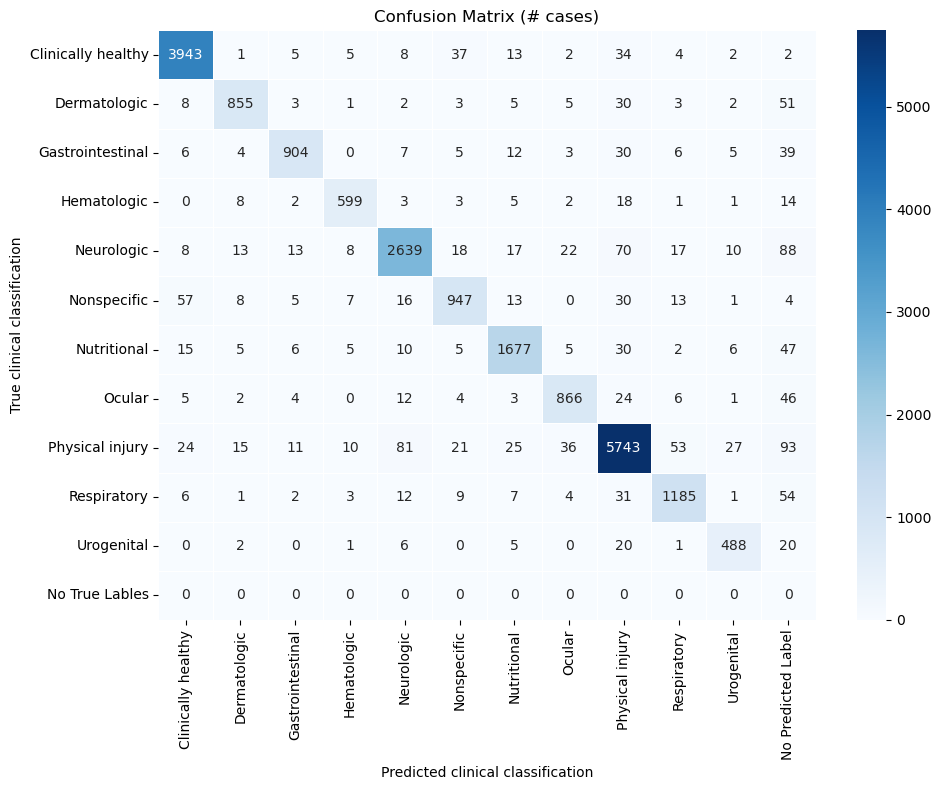

In [43]:
# Create the heatmap
plt.figure(figsize=(10,8))
ax = sns.heatmap(conf_mat, 
                cmap="Blues",
                annot=True, 
                fmt=".0f",
                linewidths=.5)

# Customize the plot
ax.set_title("Confusion Matrix (# cases)")
ax.set_xlabel("Predicted clinical classification")
ax.set_ylabel("True clinical classification")
# Set x-axis tick labels
ax.set_xticklabels(x_lables, fontsize=10, rotation = 90) 

# Set y-axis tick labels 
ax.set_yticklabels(y_lables, fontsize=10, rotation = 0)
plt.tight_layout()
plt.savefig('../reports/figures/Confusion_matrix_raw_'+today+'.png', dpi = 600)  
plt.show()

## Scores using MLCM

In [44]:
one_vs_rest = stats(conf_mat)

[[[15903   129]
  [  113  3943]]

 [[18991    59]
  [  113   855]]

 [[18942    51]
  [  117   904]]

 [[19247    40]
  [   57   599]]

 [[17207   157]
  [  284  2639]]

 [[18899   105]
  [  154   947]]

 [[18169   105]
  [  136  1677]]

 [[18980    79]
  [  107   866]]

 [[14103   317]
  [  396  5743]]

 [[18661   106]
  [  130  1185]]

 [[19358    56]
  [   55   488]]

 [[19846   458]
  [    0     0]]]

       class#     precision        recall      f1-score        weight

            0          0.97          0.97          0.97          4056
            1          0.94          0.88          0.91          968
            2          0.95          0.89          0.91          1021
            3          0.94          0.91          0.93          656
            4          0.94          0.90          0.92          2923
            5          0.90          0.86          0.88          1101
            6          0.94          0.92          0.93          1813
            7          0.92     

C:\Users\prana\Desktop\directory\WildAlertModels\notebooks\mlcm.py:207: RuntimeWarning: invalid value encountered in divide
  recall = tp/(tp+fn)


In [45]:
one_vs_rest = stats(conf_mat, False)


       class#     precision        recall      f1-score        weight

            0          0.97          0.97          0.97          4056
            1          0.94          0.88          0.91          968
            2          0.95          0.89          0.91          1021
            3          0.94          0.91          0.93          656
            4          0.94          0.90          0.92          2923
            5          0.90          0.86          0.88          1101
            6          0.94          0.92          0.93          1813
            7          0.92          0.89          0.90          973
            8          0.95          0.94          0.94          6139
            9          0.92          0.90          0.91          1315
            10          0.90          0.90          0.90          543
          NoC          There is not any data with no true-label assigned!

    micro avg          0.92          0.92          0.92          21508
    macro avg  